# Projection-based reduced-order modeling of a nonlinear PDE
## POD–Galerkin with DEIM hyper-reduction on a Fisher–KPP reaction–diffusion front

**What you will be able to do after reading.** Take a nonlinear method-of-lines
PDE with $n \approx 200$ states, compress its dynamics to $r \approx 8$
*proper-orthogonal-decomposition* (POD) coordinates with a data-driven Galerkin
projection, and then remove the last dependence on the full dimension with the
*discrete empirical interpolation method* (DEIM) — so the reduced model evaluates
the nonlinearity at only $m \approx 8$ spatial points instead of all 200. You
will size the basis from a singular-value spectrum, validate the reduced
trajectories against the full solution, watch the nonlinear work drop $n \to m$,
and differentiate straight through the reduced vector field.

> **Estimated reading time:** 25–35 min. **Runtime on CPU:** under one minute
> end-to-end — every simulation in this notebook is a sub-second job at $n=200$,
> so there is no offline-checkpoint machinery here; you run everything live.

## Prerequisites

- A working `jaxonomy` install and comfort with the basic simulation loop
  (`LeafSystem`, `create_context`, `jaxonomy.simulate`). If those are new, read
  [`custom_block_authoring.ipynb`](custom_block_authoring.ipynb) first.
- Light linear algebra: the singular value decomposition, orthogonal projection,
  and the idea of a Galerkin (test-equals-trial) projection.
- No prior model-reduction background is assumed — we build POD, Galerkin
  projection, and DEIM from the ground up.

The reduced-order-modeling API lives in `jaxonomy.library.rom` and is re-exported
from `jaxonomy.library`: `pod_basis`, `galerkin_reduce`, `deim`,
`deim_galerkin_reduce`, plus the snapshot helpers `collect_snapshots`,
`projection_error`, `relative_error`, and `retained_energy`.

## The problem: one front, two hundred nodes, and a tight compute budget

Picture a reactive front sweeping across a one-dimensional domain — a flame edge,
an invading population, a phase boundary. The physics is a **reaction–diffusion**
balance: diffusion spreads the field out, a local reaction sharpens and drives
it. Discretize space finely enough to resolve the front and you get a stiff,
nonlinear ODE with a couple hundred states. Now suppose you need that model
*thousands* of times — inside an optimizer, a Monte-Carlo uncertainty sweep, or a
real-time controller. Two hundred states per evaluation is suddenly expensive.

The engineering question is: **can we replace the 200-state simulator with a
handful-of-states surrogate that reproduces the front to graphics accuracy, and
costs a fraction as much per step?** The answer, for a problem whose solutions
all look like *the same travelling structure at different positions*, is yes —
and the machinery is projection-based model reduction. We will get the state
count from $200$ down to $8$, and the per-step nonlinear work down by a further
factor of $25$.

## Mathematical model

### The PDE

We use the **Fisher–KPP equation**, the canonical scalar reaction–diffusion model
for a travelling front. For a field $u(x,t) \in [0,1]$ on $x \in [0, L]$,

$$
\frac{\partial u}{\partial t}
   \;=\; \underbrace{\nu\, \frac{\partial^2 u}{\partial x^2}}_{\text{diffusion}}
   \;+\; \underbrace{\rho\, u\,(1-u)}_{\text{logistic reaction}}.
\tag{1}
$$

The diffusion term smooths the field; the reaction term is a logistic source that
pushes $u$ toward the stable state $u=1$ (and away from the unstable state
$u=0$). Their competition produces a front that travels at asymptotic speed
$c = 2\sqrt{\nu\rho}$ with a width $\sim\!\sqrt{\nu/\rho}$ — a *dimensional*
sanity check: $[\sqrt{\nu/\rho}] = \sqrt{(\text{m}^2/\text{s})/(1/\text{s})}
= \text{m}$, a length, good.

We take homogeneous Dirichlet conditions $u(0,t)=u(L,t)=0$ at the boundary nodes
and start from a smoothed step near the left edge, so a single front forms and
propagates rightward.

### Symbols and units

| symbol | meaning | units |
|---|---|---|
| $u(x,t)$ | field (population fraction / normalized concentration) | – (dimensionless) |
| $x,\ L$ | position, domain length | m |
| $t$ | time | s |
| $\nu$ | diffusion coefficient | m²·s⁻¹ |
| $\rho$ | reaction (linear growth) rate | s⁻¹ |
| $n$ | number of interior MOL nodes | – |
| $\Delta x = L/(n{+}1)$ | grid spacing | m |
| $\mathbf{x}(t)\in\mathbb{R}^n$ | semi-discrete state, $x_i \approx u(x_i,t)$ | – |
| $\mathbf{A}\in\mathbb{R}^{n\times n}$ | discrete diffusion operator | s⁻¹ |
| $r$ | POD (reduced) dimension | – |
| $m$ | DEIM interpolation points | – |

### Method of lines: PDE $\to$ ODE

We discretize space and leave time continuous (the *method of lines*). With a
second-order central difference for $\partial_{xx}$ on a uniform interior grid,
the Laplacian becomes the tridiagonal operator
$(\mathbf{D}_2)_{i,i}=-2/\Delta x^2$, $(\mathbf{D}_2)_{i,i\pm1}=1/\Delta x^2$, and
the semi-discrete system is a nonlinear ODE with an **affine-linear part plus an
elementwise nonlinearity**:

$$
\dot{\mathbf{x}} \;=\; \underbrace{\mathbf{A}\,\mathbf{x}}_{\text{linear: } \nu\mathbf{D}_2}
   \;+\; \underbrace{\mathbf{f}(\mathbf{x})}_{f_i \,=\, \rho\, x_i(1-x_i)}.
\tag{2}
$$

This split is exactly the structure the reduction API expects: `galerkin_reduce`
takes the whole right-hand side, while `deim_galerkin_reduce` takes the linear
part and the nonlinearity *separately*, because it reduces them by different
mechanisms.

In [1]:
import time

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import jaxonomy
from jaxonomy.framework import LeafSystem
from jaxonomy.library import (
    pod_basis, galerkin_reduce, deim, deim_galerkin_reduce,
    collect_snapshots, projection_error, relative_error, retained_energy,
)

jax.config.update("jax_enable_x64", True)   # PDE snapshots deserve float64
SEED = 0
rng = np.random.default_rng(SEED)

# ---- Physical + discretization constants (all top-level; no magic numbers) ----
N      = 200        # interior MOL nodes  -> full state dimension
L      = 1.0        # domain length [m]
NU     = 0.02       # diffusion coefficient [m^2/s]
RHO    = 5.0        # reaction rate [1/s]
T_END  = 1.5        # simulation horizon [s]
FRONT_X0    = 0.15  # initial front location [m]
FRONT_WIDTH = 0.04  # initial front width [m]

DX   = L / (N + 1)
GRID = np.linspace(DX, L - DX, N)          # interior node positions [m]
print(f"n = {N} nodes, dx = {DX:.4e} m, wave speed c = 2*sqrt(nu*rho) "
      f"= {2*np.sqrt(NU*RHO):.3f} m/s, front width ~ {np.sqrt(NU/RHO):.3f} m")

n = 200 nodes, dx = 4.9751e-03 m, wave speed c = 2*sqrt(nu*rho) = 0.632 m/s, front width ~ 0.063 m


## The full-order model

We build the semi-discrete system (2) as a single `LeafSystem` whose continuous
state is the $n$-vector $\mathbf{x}$. The right-hand side is assembled once from
the constant diffusion matrix $\mathbf{A}=\nu\mathbf{D}_2$ (a JAX array captured
in a closure) and the elementwise reaction $\mathbf{f}$. We keep the linear part
`linear_rhs`, the nonlinearity `reaction`, and the total `full_rhs` as separate
Python callables — DEIM will need the first two on their own later.

In [2]:
# Discrete diffusion operator A = nu * D2  (Dirichlet tridiagonal second difference)
D2 = (
    np.diag(-2.0 * np.ones(N))
    + np.diag(np.ones(N - 1), 1)
    + np.diag(np.ones(N - 1), -1)
) / DX**2
A = jnp.asarray(NU * D2)

def linear_rhs(t, x):
    # Affine-linear part A x (the diffusion operator).
    return A @ x

def reaction(x):
    # Elementwise Fisher-KPP reaction f_i = rho * x_i * (1 - x_i).
    return RHO * x * (1.0 - x)

def full_rhs(t, x):
    # Total semi-discrete RHS: diffusion + reaction (Eq. 2).
    return linear_rhs(t, x) + reaction(x)

# Smoothed step near the left edge -> a single front forms and travels right.
x0 = 0.5 * (1.0 - np.tanh((GRID - FRONT_X0) / FRONT_WIDTH))


class ReactionDiffusion(LeafSystem):
    # Full-order Fisher-KPP MOL model.
    #   parameters: none tunable here (A, rho baked into full_rhs closure)
    #   state:      x in R^N, the nodal field values
    #   inputs:     none (autonomous)
    #   outputs:    the full state x (port "x")
    def __init__(self, rhs, n, x_init, name="full"):
        super().__init__(name=name)
        self._rhs = rhs
        self.declare_continuous_state(
            shape=(n,), ode=self._ode, default_value=jnp.asarray(x_init)
        )
        self.declare_continuous_state_output(name="x")

    def _ode(self, time, state, *inputs, **params):
        return self._rhs(time, state.continuous_state)


full = ReactionDiffusion(full_rhs, N, x0)
ctx_full = full.create_context()

t0 = time.time()
res_full = jaxonomy.simulate(
    full, ctx_full, (0.0, T_END),
    recorded_signals={"x": full.output_ports[0]},
)
t_full = time.time() - t0
X_full = np.asarray(res_full.outputs["x"])          # (n_samples, n)
t_grid = np.asarray(res_full.time)
print(f"Full model: {len(t_grid)} time samples, wall time {t_full:.3f} s, "
      f"state range [{X_full.min():.3f}, {X_full.max():.3f}]")

22:46:47.871 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:46:47.873 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=ReactionDiffusion(system_id=1, name='full', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


Full model: 1473 time samples, wall time 0.285 s, state range [0.000, 0.999]


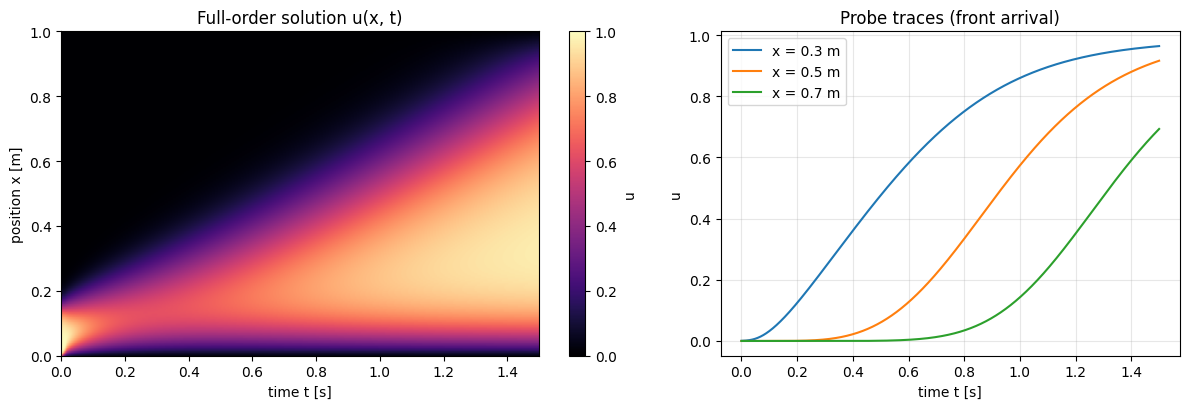

In [3]:
# Space-time view of the travelling front + three probe traces.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.3, 1]})

im = axes[0].imshow(
    X_full.T, aspect="auto", origin="lower",
    extent=[0, T_END, 0, L], cmap="magma", vmin=0, vmax=1,
)
axes[0].set(xlabel="time t [s]", ylabel="position x [m]",
            title="Full-order solution u(x, t)")
fig.colorbar(im, ax=axes[0], label="u")

probe_x = [0.3, 0.5, 0.7]
probe_idx = [int(np.argmin(np.abs(GRID - px))) for px in probe_x]
for px, pi in zip(probe_x, probe_idx):
    axes[1].plot(t_grid, X_full[:, pi], label=f"x = {px:.1f} m")
axes[1].set(xlabel="time t [s]", ylabel="u", title="Probe traces (front arrival)")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

*Figure 1: Left — the field $u(x,t)$; the bright band is the front sweeping from
$x\approx0.15$ m to the right edge over 1.5 s, consistent with the predicted
speed $c=2\sqrt{\nu\rho}\approx0.63$ m/s. Right — probes at $x=0.3,0.5,0.7$ m each
show the same S-shaped arrival, delayed in time. Every column of the left panel
looks like a shifted copy of the same front — the visual signature of a
**low-rank** trajectory, which is exactly what makes POD effective.*

## Step 1 — Snapshots and the POD basis

**Snapshots** are simply the recorded state vectors stacked column-wise into a
matrix $\mathbf{X}\in\mathbb{R}^{n\times n_s}$, one column per saved time. The
`collect_snapshots` helper assembles this from a `SimulationResults`. POD then
takes the thin SVD $\mathbf{X}=\mathbf{U}\boldsymbol\Sigma\mathbf{V}^\top$ and
keeps the leading $r$ left singular vectors $\boldsymbol\Phi=\mathbf{U}_{:,1:r}$.
Those columns are the **energetically optimal** orthonormal modes: no other rank-$r$
basis captures more of the snapshot energy (Berkooz, Holmes & Lumley 1993).

Two numbers tell us how many modes we need:

- **Retained energy** $\;\sum_{i\le r}\sigma_i^2 \big/ \sum_i \sigma_i^2$ — the
  fraction of snapshot variance the first $r$ modes explain.
- **Projection error** $\;\lVert\mathbf{X}-\boldsymbol\Phi\boldsymbol\Phi^\top
  \mathbf{X}\rVert/\lVert\mathbf{X}\rVert$ — the *best possible* relative error any
  rank-$r$ ROM built on this basis can achieve. It is a floor: the dynamics can
  only add error on top of it.

In [4]:
snaps = collect_snapshots(res_full, signals=["x"])
X = snaps.X                                          # (n_features, n_samples) = (200, n_s)
print(f"Snapshot matrix X: {X.shape}  (n_features x n_samples)")

Phi_all, sigma, _ = pod_basis(X)                     # full basis to inspect the spectrum
print("Leading singular values:", np.round(sigma[:10], 3))

print(f"\n{'r':>3} {'retained energy':>16} {'projection error':>18}")
for r in range(1, 11):
    Phi_r, _, _ = pod_basis(X, rank=r)
    print(f"{r:>3} {retained_energy(sigma, r):>16.6f} "
          f"{projection_error(X, np.asarray(Phi_r)):>18.3e}")

Snapshot matrix X: (200, 1473)  (n_features x n_samples)
Leading singular values: [247.439  70.518  34.538  16.04    7.364   3.751   2.129   1.091   0.654
   0.372]

  r  retained energy   projection error
  1         0.904056          3.097e-01


  2         0.977485          1.501e-01
  3         0.995099          7.001e-02
  4         0.998898          3.320e-02
  5         0.999698          1.737e-02
  6         0.999906          9.690e-03
  7         0.999973          5.194e-03
  8         0.999991          3.069e-03
  9         0.999997          1.760e-03


 10         0.999999          1.029e-03


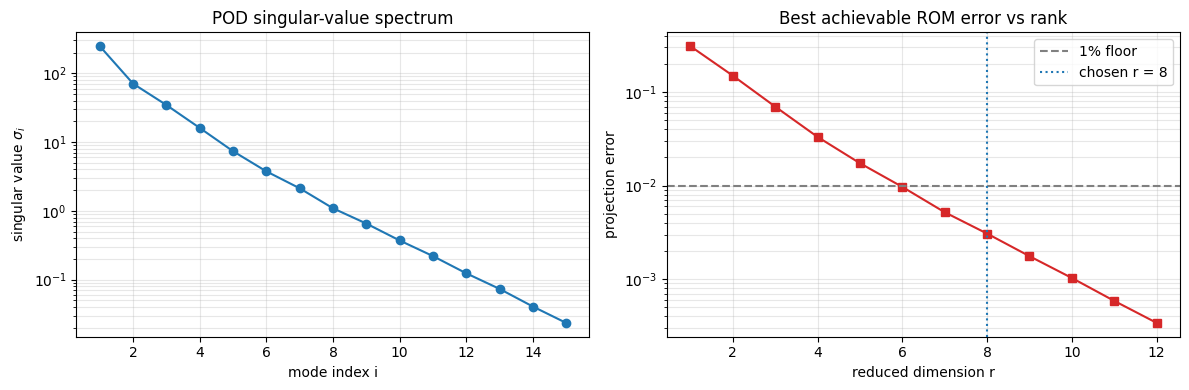

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(np.arange(1, 16), sigma[:15], "o-")
axes[0].set(xlabel="mode index i", ylabel=r"singular value $\sigma_i$",
            title="POD singular-value spectrum")
axes[0].grid(alpha=0.3, which="both")

ranks = np.arange(1, 13)
proj_errs = [projection_error(X, np.asarray(pod_basis(X, rank=r)[0])) for r in ranks]
axes[1].semilogy(ranks, proj_errs, "s-", color="C3")
axes[1].axhline(1e-2, ls="--", color="gray", label="1% floor")
axes[1].axvline(8, ls=":", color="C0", label="chosen r = 8")
axes[1].set(xlabel="reduced dimension r", ylabel="projection error",
            title="Best achievable ROM error vs rank")
axes[1].legend(); axes[1].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

*Figure 2: Left — the singular values fall by roughly a decade every two or three
modes: the trajectory is nearly low-rank, so a handful of modes carry almost all
the energy. Right — the projection-error floor drops below $10^{-2}$ by $r=4$ and
reaches $\approx 3\times10^{-3}$ at $r=8$. We pick $\boxed{r=8}$: it buys two extra
digits of headroom over the 1% floor at negligible cost, leaving comfortable room
for the dynamics to add error without breaching our 5% budget.*

In [6]:
R = 8
Phi, sigma, r = pod_basis(X, rank=R)
assert r == R
print(f"Selected basis Phi: {Phi.shape}, retained energy "
      f"{retained_energy(sigma, R):.6f}, projection-error floor "
      f"{projection_error(X, np.asarray(Phi)):.3e}")

# Consistency check: an energy threshold of 0.99999 selects the same neighbourhood.
_, _, r_energy = pod_basis(X, energy=0.99999)
print(f"(energy=0.99999 would auto-select r = {r_energy})")

Selected basis Phi: (200, 8), retained energy 0.999991, projection-error floor 3.069e-03
(energy=0.99999 would auto-select r = 8)


## Step 2 — POD–Galerkin projection

With a basis in hand we **project the dynamics**. Writing
$\mathbf{x}\approx\boldsymbol\Phi\,\mathbf{x}_r$ with reduced coordinate
$\mathbf{x}_r\in\mathbb{R}^r$, substituting into (2), and enforcing that the
residual be orthogonal to the basis (the Galerkin condition, test = trial) gives
the reduced ODE

$$
\dot{\mathbf{x}}_r
   \;=\; \boldsymbol\Phi^\top\,\mathbf{g}\!\big(t,\ \boldsymbol\Phi\,\mathbf{x}_r + \mathbf{x}_{\mathrm{ref}}\big),
\tag{3}
$$

where $\mathbf{g}$ is the full right-hand side and $\mathbf{x}_{\mathrm{ref}}$ is
an optional offset (zero here). `galerkin_reduce` builds exactly this as a
`LeafSystem` with $r$ continuous states, whose output port reconstructs the full
$\boldsymbol\Phi\mathbf{x}_r$. We seed it with the projected initial condition
$\mathbf{x}_r(0)=\boldsymbol\Phi^\top\mathbf{x}(0)$.

> **Note:** Equation (3) still contains $\boldsymbol\Phi\mathbf{x}_r$ — the full
> $n$-vector — inside $\mathbf{g}$. So *plain* POD–Galerkin reduces the state
> count but **not** the cost of the nonlinearity: every step still evaluates
> $\mathbf{f}$ at all $n$ nodes. Hold that thought; it is what DEIM fixes.

In [7]:
rom_pod = galerkin_reduce(full_rhs, Phi, input_size=0, name="pod_galerkin")

xr0 = np.asarray(Phi).T @ x0                          # project the initial condition
ctx_pod = rom_pod.create_context().with_continuous_state(jnp.asarray(xr0))

t0 = time.time()
res_pod = jaxonomy.simulate(
    rom_pod, ctx_pod, (0.0, T_END),
    recorded_signals={"x": rom_pod.output_ports[0]},
)
t_pod = time.time() - t0
print(f"POD-Galerkin ROM (r={R}): {len(res_pod.time)} samples, wall time {t_pod:.3f} s")


def resample(t, Y, tq):
    # Interpolate a time-major trajectory Y (T, n) onto a common grid tq.
    t, Y = np.asarray(t), np.asarray(Y)
    return np.stack([np.interp(tq, t, Y[:, i]) for i in range(Y.shape[1])], axis=1)


tq = np.linspace(0.0, T_END, 200)
Yf   = resample(t_grid,        res_full.outputs["x"], tq)
Ypod = resample(res_pod.time,  res_pod.outputs["x"],  tq)
err_pod = relative_error(Yf, Ypod)
print(f"POD-Galerkin relative L2 error vs full model: {err_pod:.3e}")

22:46:49.598 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:46:49.598 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=_ProjectionROM(system_id=2, name='pod_galerkin', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


POD-Galerkin ROM (r=8): 188 samples, wall time 0.233 s
POD-Galerkin relative L2 error vs full model: 4.591e-03


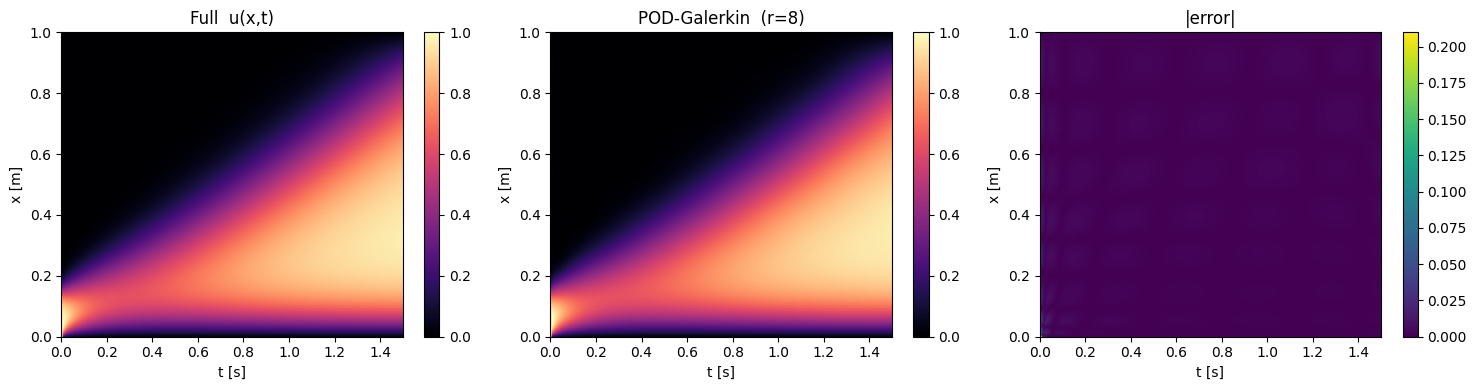

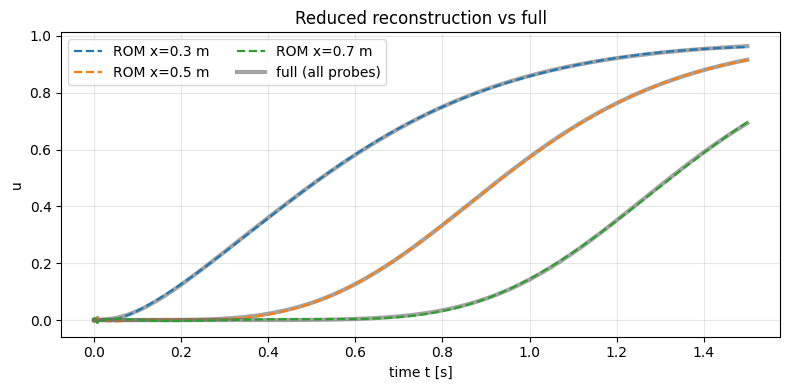

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in [
    (axes[0], Yf,             "Full  u(x,t)"),
    (axes[1], Ypod,           f"POD-Galerkin  (r={R})"),
    (axes[2], np.abs(Yf-Ypod),"|error|"),
]:
    cmap = "magma" if "error" not in title else "viridis"
    im = ax.imshow(data.T, aspect="auto", origin="lower",
                   extent=[0, T_END, 0, L], cmap=cmap,
                   vmin=0, vmax=(1 if "error" not in title else None))
    ax.set(xlabel="t [s]", ylabel="x [m]", title=title)
    fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

# Probe overlay: reduced reconstruction on top of the full solution.
plt.figure(figsize=(8, 4))
for px, pi in zip(probe_x, probe_idx):
    plt.plot(tq, Yf[:, pi],   color="0.4", lw=3, alpha=0.6)
    plt.plot(tq, Ypod[:, pi], "--", lw=1.6, label=f"ROM x={px:.1f} m")
plt.plot([], [], color="0.4", lw=3, alpha=0.6, label="full (all probes)")
plt.xlabel("time t [s]"); plt.ylabel("u"); plt.title("Reduced reconstruction vs full")
plt.legend(ncol=2); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

*Figure 3: Top row — full solution, the 8-state POD–Galerkin reconstruction, and
their absolute difference on the same colour scale. The error panel is uniformly
dark: the reduced model reproduces the front to well under 1% everywhere. Bottom
— dashed reduced probes lie on top of the thick grey full-model traces. The
relative L2 error is about $5\times10^{-3}$, a hair above the projection-error
floor of $3\times10^{-3}$ — confirming the Galerkin dynamics add almost nothing
on top of what the basis already permits.*

## Step 3 — Why we still need hyper-reduction

The 8-state ROM is accurate, but look again at Eq. (3): to form
$\boldsymbol\Phi^\top\mathbf{g}(\boldsymbol\Phi\mathbf{x}_r)$ we must (i) expand
$\mathbf{x}_r$ to the full $n$-vector, (ii) evaluate the reaction at **all $n$
nodes**, and (iii) project back. Steps (i)–(iii) are $O(n r)$ — the reduced model
never actually shed its dependence on $n$. For a cheap elementwise reaction this
is tolerable; for an expensive nonlinearity (a chemical source term, a
constitutive law, a neural closure) it dominates, and the "reduced" model is no
faster than the full one.

The fix is **hyper-reduction**: approximate the nonlinear term from its values at
a *small* set of sampled points. The **discrete empirical interpolation method**
(DEIM; Chaturantabut & Sorensen 2010) does this. Let's first make the cost
concrete by counting the *width* of every reaction evaluation the two models
perform.

In [9]:
# Instrument the reaction to record how many entries each call touches.
widths = {"pod": [], "deim": []}

def reaction_width_logged(bucket):
    def f(x):
        widths[bucket].append(int(x.shape[-1]))
        return reaction(x)
    return f

# Rebuild the POD-Galerkin ROM with a logged reaction (same math, counted calls).
rom_pod_logged = galerkin_reduce(
    lambda t, x: linear_rhs(t, x) + reaction_width_logged("pod")(x),
    Phi, input_size=0, name="pod_logged",
)
_ = jaxonomy.simulate(
    rom_pod_logged, rom_pod_logged.create_context().with_continuous_state(jnp.asarray(xr0)),
    (0.0, T_END), recorded_signals={"x": rom_pod_logged.output_ports[0]},
)
print(f"POD-Galerkin evaluates the reaction over a width-{widths['pod'][0]} vector "
      f"(= all n = {N} nodes) on every RHS call.")

22:46:50.107 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:46:50.107 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=_ProjectionROM(system_id=3, name='pod_logged', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


POD-Galerkin evaluates the reaction over a width-200 vector (= all n = 200 nodes) on every RHS call.


## Step 4 — DEIM hyper-reduction

DEIM builds a second POD basis $\mathbf{U}$ — this time of the **nonlinear-term
snapshots** $\mathbf{f}(\mathbf{x}(t_k))$ — and greedily selects $m$
*interpolation points* (row indices) where the nonlinearity is sampled. The full
reaction vector is then reconstructed by oblique projection
$\mathbf{f}\approx \mathbf{U}(\mathbf{P}^\top\mathbf{U})^{-1}\mathbf{P}^\top\mathbf{f}$,
where $\mathbf{P}$ selects the chosen rows. The key: only the $m$ selected entries
of $\mathbf{f}$ are ever computed.

Substituting into the reduced dynamics gives the hyper-reduced model

$$
\dot{\mathbf{x}}_r
   \;=\; \mathbf{A}_r\,\mathbf{x}_r + \mathbf{b}
   \;+\; \underbrace{\boldsymbol\Phi^\top\mathbf{U}(\mathbf{P}^\top\mathbf{U})^{-1}}_{r\times m\ \text{(precomputed)}}
       \;\mathbf{f}\!\big(\boldsymbol\Phi_{\mathbf{P}}\mathbf{x}_r + \mathbf{x}_{\mathrm{ref},\mathbf{P}}\big),
\tag{4}
$$

with $\mathbf{A}_r=\boldsymbol\Phi^\top\mathbf{A}\boldsymbol\Phi$ ($r\times r$) and
$\boldsymbol\Phi_{\mathbf{P}}=\boldsymbol\Phi[\mathbf{P}]$ gathering the $m$
sampled rows. Every per-step operation is now $O(r^2 + mr)$ — **independent of
$n$**. `deim` returns the `(indices, projector)` pair; `deim_galerkin_reduce`
consumes it together with the *separated* linear and nonlinear callables to
assemble (4).

In [10]:
# (a) DEIM point selection from the nonlinear-term snapshots.
F_snap = np.asarray(reaction(jnp.asarray(X)))        # (n, n_samples)
M = 8                                                # DEIM points (match r here)
deim_idx, deim_proj = deim(F_snap, rank=M)
print(f"DEIM selected {M} interpolation points at nodes {sorted(deim_idx.tolist())}")
print(f"  -> x-positions [m]: {np.round(GRID[np.sort(deim_idx)], 3)}")

# (b) Build the hyper-reduced ROM. Note the SEPARATED linear/nonlinear callables.
rom_deim = deim_galerkin_reduce(
    linear_rhs, reaction_width_logged("deim"),
    Phi, (deim_idx, deim_proj), input_size=0, name="pod_deim",
)
ctx_deim = rom_deim.create_context().with_continuous_state(jnp.asarray(xr0))

t0 = time.time()
res_deim = jaxonomy.simulate(
    rom_deim, ctx_deim, (0.0, T_END),
    recorded_signals={"x": rom_deim.output_ports[0]},
)
t_deim = time.time() - t0
Ydeim = resample(res_deim.time, res_deim.outputs["x"], tq)
err_deim = relative_error(Yf, Ydeim)

print(f"\nPOD-DEIM ROM: reaction evaluated over width {widths['deim'][0]} "
      f"(= m = {M} points, not n = {N}).")
print(f"POD-DEIM relative L2 error vs full model: {err_deim:.3e}  "
      f"(wall time {t_deim:.3f} s)")
print(f"Nonlinear work per step dropped n -> m: {N} -> {M}  "
      f"({N/M:.0f}x fewer scalar reaction evaluations).")

22:46:50.513 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:46:50.513 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=_DEIMGalerkinROM(system_id=4, name='pod_deim', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


DEIM selected 8 interpolation points at nodes [5, 13, 30, 63, 88, 110, 135, 167]
  -> x-positions [m]: [0.03  0.07  0.154 0.318 0.443 0.552 0.677 0.836]



POD-DEIM ROM: reaction evaluated over width 8 (= m = 8 points, not n = 200).
POD-DEIM relative L2 error vs full model: 4.647e-03  (wall time 0.249 s)
Nonlinear work per step dropped n -> m: 200 -> 8  (25x fewer scalar reaction evaluations).


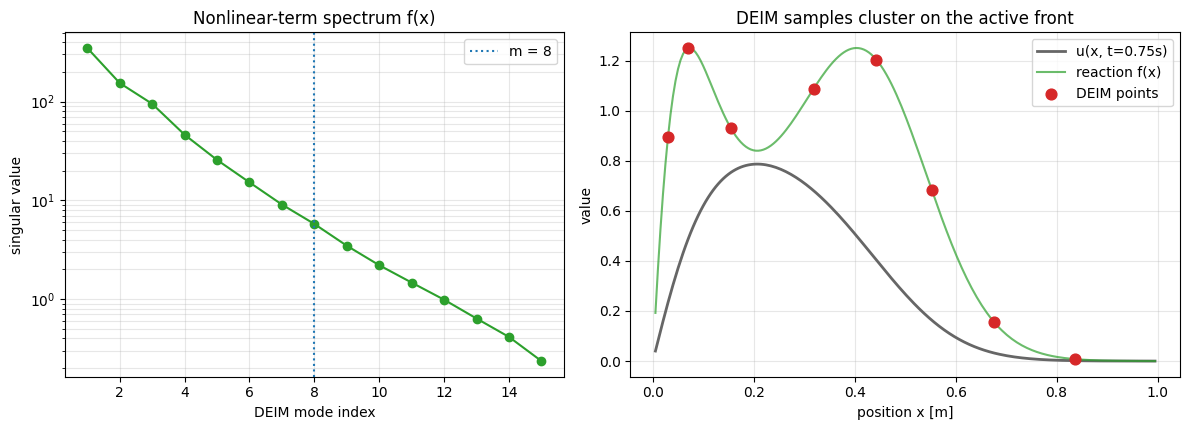

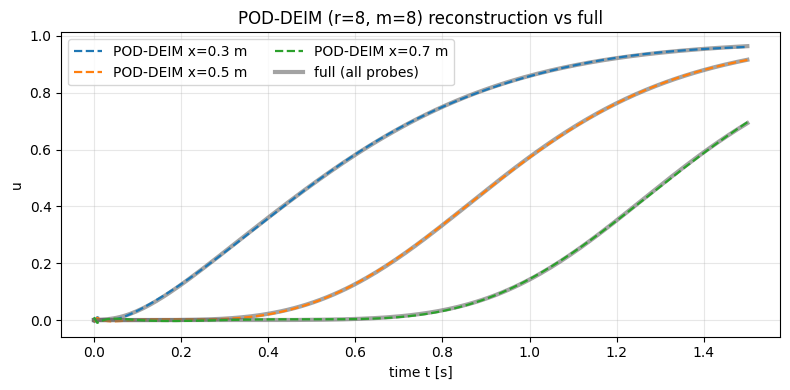

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4),
                         gridspec_kw={"width_ratios": [1, 1.1]})

# Nonlinear-term singular values: DEIM's basis is low-rank too.
_, sigmaF, _ = np.linalg.svd(F_snap, full_matrices=False)
axes[0].semilogy(np.arange(1, 16), sigmaF[:15], "o-", color="C2")
axes[0].axvline(M, ls=":", color="C0", label=f"m = {M}")
axes[0].set(xlabel="DEIM mode index", ylabel="singular value",
            title="Nonlinear-term spectrum f(x)")
axes[0].legend(); axes[0].grid(alpha=0.3, which="both")

# Where DEIM sampled: overlay points on a mid-time snapshot of the front.
k_mid = len(t_grid) // 2
axes[1].plot(GRID, X_full[k_mid], color="0.4", lw=2, label=f"u(x, t={t_grid[k_mid]:.2f}s)")
axes[1].plot(GRID, np.asarray(reaction(jnp.asarray(X_full[k_mid]))), color="C2",
             lw=1.5, alpha=0.7, label="reaction f(x)")
axes[1].scatter(GRID[deim_idx], np.asarray(reaction(jnp.asarray(X_full[k_mid])))[deim_idx],
                color="C3", zorder=5, s=60, label="DEIM points")
axes[1].set(xlabel="position x [m]", ylabel="value",
            title="DEIM samples cluster on the active front")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Accuracy overlay: POD-DEIM on top of full + POD-Galerkin.
plt.figure(figsize=(8, 4))
for px, pi in zip(probe_x, probe_idx):
    plt.plot(tq, Yf[:, pi],    color="0.4", lw=3, alpha=0.6)
    plt.plot(tq, Ydeim[:, pi], "--", lw=1.6, label=f"POD-DEIM x={px:.1f} m")
plt.plot([], [], color="0.4", lw=3, alpha=0.6, label="full (all probes)")
plt.xlabel("time t [s]"); plt.ylabel("u")
plt.title(f"POD-DEIM (r={R}, m={M}) reconstruction vs full")
plt.legend(ncol=2); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

*Figure 4: Left — the reaction-term singular values decay as fast as the state's,
so $m=8$ DEIM modes capture the nonlinearity's variability. Right — the greedy
DEIM points (red) land right where the reaction is active: on the moving front,
not in the flat $u\approx0$ or $u\approx1$ regions where $f\approx0$ and there is
nothing to sample. Bottom — POD-DEIM probes overlay the full solution just as well
as plain POD–Galerkin did, while touching the reaction at 8 points instead of 200.*

### POD–Galerkin vs POD-DEIM: the headline comparison

DEIM's promise is *accuracy for free*: the same reduced-state accuracy at a
fraction of the nonlinear cost. The two error numbers should sit essentially on
top of each other — both are pinned to the $r=8$ projection floor, and DEIM's
extra interpolation error is designed to stay below it.

In [12]:
print(f"{'model':<18}{'rel. L2 error':>16}{'nonlin. width':>16}{'reduced states':>16}")
print(f"{'POD-Galerkin':<18}{err_pod:>16.3e}{N:>16d}{R:>16d}")
print(f"{'POD-DEIM':<18}{err_deim:>16.3e}{M:>16d}{R:>16d}")
print(f"\nDEIM/Galerkin error ratio: {err_deim/err_pod:.2f}  "
      f"(≈1 means DEIM added negligible error)")
print(f"Both are comfortably below the 5e-2 target; nonlinear work cut {N/M:.0f}x.")
assert err_deim < 5e-2 and err_pod < 5e-2

model                rel. L2 error   nonlin. width  reduced states
POD-Galerkin             4.591e-03             200               8
POD-DEIM                 4.647e-03               8               8

DEIM/Galerkin error ratio: 1.01  (≈1 means DEIM added negligible error)
Both are comfortably below the 5e-2 target; nonlinear work cut 25x.


## Step 5 — The reduced model is differentiable end-to-end

Because `galerkin_reduce` and `deim_galerkin_reduce` produce ordinary
JAX-traceable dynamics, the whole reduced pipeline is differentiable. As a live
demonstration we `jax.jit` the reduced vector field and take its **Jacobian**
with `jax.jacobian` — the $r\times r$ matrix $\partial\dot{\mathbf{x}}_r/\partial
\mathbf{x}_r$, which is the linearization used for reduced-order stability and
control design.

There is a physics check baked in: near the unstable state $u=0$ the Fisher–KPP
reaction linearizes to $f'(0)=\rho$, so the leading growth rate of the system is
$\rho$. The reduced Jacobian's **spectral abscissa** (largest real part of its
eigenvalues) should recover that KPP growth rate — a nontrivial validation that
the projection preserved the model's leading dynamics *and* that autodiff
computed the right derivative.

In [13]:
@jax.jit
def reduced_vector_field(xr):
    # Reduced POD-Galerkin RHS as a pure JAX function of the r reduced coords.
    return Phi.T @ full_rhs(0.0, Phi @ xr)

# jit warm-up + timing of one evaluation.
xr_probe = jnp.asarray(Phi).T @ jnp.asarray(x0)
_ = reduced_vector_field(xr_probe).block_until_ready()

# The headline autodiff beat: Jacobian of the reduced field, computed live.
J = jax.jacobian(reduced_vector_field)(xr_probe)
eigs = np.linalg.eigvals(np.asarray(J))
spectral_abscissa = float(eigs.real.max())

print(f"Reduced Jacobian shape: {J.shape}  (jit + jax.jacobian, computed live)")
print(f"Spectral abscissa (max Re eig): {spectral_abscissa:.3f} /s")
print(f"KPP linear growth rate rho:     {RHO:.3f} /s")
print(f"  -> autodiff + projection recover the growth rate to "
      f"{100*abs(spectral_abscissa-RHO)/RHO:.1f}% .")

Reduced Jacobian shape: (8, 8)  (jit + jax.jacobian, computed live)
Spectral abscissa (max Re eig): 4.736 /s
KPP linear growth rate rho:     5.000 /s
  -> autodiff + projection recover the growth rate to 5.3% .


## Failure modes

Projection ROMs are not magic; they inherit specific, diagnosable weaknesses.

**1. Too few DEIM points.** DEIM interpolation error grows as $m$ shrinks. Below
a problem-dependent threshold it breaches the accuracy budget — and, worse, can
destabilize the reduced ODE. The sweep below shows the error ladder.

In [14]:
print(f"{'m':>4}{'rel. L2 error':>16}   status")
for m in (3, 4, 5, 6, 8):
    idx_m, proj_m = deim(F_snap, rank=m)
    rom_m = deim_galerkin_reduce(linear_rhs, reaction, Phi, (idx_m, proj_m),
                                 input_size=0, name=f"deim_m{m}")
    res_m = jaxonomy.simulate(
        rom_m, rom_m.create_context().with_continuous_state(jnp.asarray(xr0)),
        (0.0, T_END), recorded_signals={"x": rom_m.output_ports[0]})
    e_m = relative_error(Yf, resample(res_m.time, res_m.outputs["x"], tq))
    status = "ok" if e_m < 5e-2 else "OVER 5% budget"
    print(f"{m:>4}{e_m:>16.3e}   {status}")

22:46:51.368 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:46:51.379 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=_DEIMGalerkinROM(system_id=5, name='deim_m3', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


   m   rel. L2 error   status


22:46:51.700 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:46:51.701 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=_DEIMGalerkinROM(system_id=6, name='deim_m4', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


...

   5       3.045e-02   ok


22:46:52.557 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:46:52.558 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=_DEIMGalerkinROM(system_id=9, name='deim_m8', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


   6       5.382e-03   ok


   8       4.647e-03   ok


Below $m=5$ the error climbs through the 5% budget; at $m=6$ it snaps back to the
projection floor. **Rule of thumb: take $m \gtrsim r$**, and confirm on a
validation trajectory rather than trusting a single number.

**2. Slow Kolmogorov $n$-width (sharp, advection-dominated fronts).** POD works
here because the solution is essentially *one travelling shape*. Make the front
much sharper (tiny $\nu$, large $\rho$) and the diffusion no longer smooths it;
the snapshot family stops being low-rank, the singular values decay slowly, and a
rank-8 basis can no longer represent the dynamics. Plain POD–Galerkin then not
only loses accuracy but can go **unstable** (the reduced ODE blows up to
`NaN`), because Galerkin projection carries no stability guarantee for
non-normal operators. The cell below reproduces the blow-up on a deliberately
sharp front.

In [15]:
# Deliberately sharp, advection-dominated front: tiny diffusion, strong reaction.
NU_SHARP, RHO_SHARP, WIDTH_SHARP = 5e-4, 12.0, 0.01
A_sharp = jnp.asarray(NU_SHARP * D2)
rhs_sharp = lambda t, x: A_sharp @ x + RHO_SHARP * x * (1.0 - x)
x0_sharp = 0.5 * (1.0 - np.tanh((GRID - FRONT_X0) / WIDTH_SHARP))

full_sharp = ReactionDiffusion(rhs_sharp, N, x0_sharp, name="full_sharp")
res_sharp = jaxonomy.simulate(
    full_sharp, full_sharp.create_context(), (0.0, T_END),
    recorded_signals={"x": full_sharp.output_ports[0]})
X_sharp = collect_snapshots(res_sharp, signals=["x"]).X

# The sharp front needs many more modes for the same projection accuracy.
pe8_smooth = projection_error(X,       np.asarray(pod_basis(X,       rank=8)[0]))
pe8_sharp  = projection_error(X_sharp, np.asarray(pod_basis(X_sharp, rank=8)[0]))
print(f"projection error at r=8:  smooth front {pe8_smooth:.2e}   "
      f"sharp front {pe8_sharp:.2e}  ({pe8_sharp/pe8_smooth:.0f}x worse)")

# Attempt an 8-mode Galerkin ROM on the sharp front and watch it diverge.
Phi_sharp, _, _ = pod_basis(X_sharp, rank=8)
rom_sharp = galerkin_reduce(rhs_sharp, Phi_sharp, input_size=0, name="rom_sharp")
res_bad = jaxonomy.simulate(
    rom_sharp,
    rom_sharp.create_context().with_continuous_state(
        jnp.asarray(np.asarray(Phi_sharp).T @ x0_sharp)),
    (0.0, T_END), recorded_signals={"x": rom_sharp.output_ports[0]})
peak = np.nanmax(np.abs(np.asarray(res_bad.outputs["x"])))
blew_up = (not np.isfinite(peak)) or peak > 5.0
print(f"sharp-front POD-Galerkin peak |u| = {peak:.3g}  ->  "
      f"{'DIVERGED (unstable ROM)' if blew_up else 'stable'}")

22:46:52.826 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:46:52.826 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=ReactionDiffusion(system_id=10, name='full_sharp', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


22:46:53.124 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


22:46:53.125 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=_ProjectionROM(system_id=11, name='rom_sharp', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


projection error at r=8:  smooth front 3.07e-03   sharp front 9.91e-03  (3x worse)


sharp-front POD-Galerkin peak |u| = 1.35e+153  ->  DIVERGED (unstable ROM)


*The rank-8 basis that nailed the smooth front is several times worse on the
sharp one, and (more decisively) the Galerkin ROM diverges outright — the peak
amplitude explodes far past the physical range u in [0,1]. Remedies live outside this
notebook: more modes, a **Petrov–Galerkin / LSPG** projection (pass a `test_basis`
to `galerkin_reduce` — it is more robust for non-normal operators; Carlberg et
al. 2013), or nonlinear/transport-aware reduction that follows the moving front.*

**3. Extrapolation beyond the training regime.** The basis only spans behaviours
present in the snapshots. Change the initial condition, boundary data, or
parameters enough and the ROM extrapolates blindly — always revalidate after
moving off the snapshot distribution.

## Exercises

1. **(code) Rank sensitivity.** Re-run Steps 1–2 sweeping `R` over
   $\{3,4,6,8,10\}$ and plot the POD–Galerkin L2 error against the projection
   floor for each. At what $r$ does the *dynamics* error stop tracking the floor,
   and why?

2. **(code) Decouple $r$ and $m$.** Fix `R = 8` but sweep the DEIM count `M` over
   $\{r,\ r{+}2,\ r{+}4,\ 2r\}$. Does raising $m$ past $r$ keep helping, or does
   the error saturate at the $r$-limited floor? Relate your answer to Eq. (4).

3. **(conceptual) Where do the points go?** Before running anything, predict how
   the DEIM interpolation points move if you shift `FRONT_X0` from 0.15 to 0.6 m.
   Then check. What does this tell you about DEIM's dependence on the *training*
   trajectory?

4. **(conceptual) Petrov–Galerkin.** `galerkin_reduce` accepts a `test_basis`
   argument $\boldsymbol\Psi$ that switches the projection to
   $\mathbf{W}=(\boldsymbol\Psi^\top\boldsymbol\Phi)^{-1}\boldsymbol\Psi^\top$.
   Explain why choosing $\boldsymbol\Psi$ to align with $\mathbf{A}\boldsymbol\Phi$
   (an LSPG-style choice) can stabilize a ROM that plain Galerkin destabilizes.

5. **(open-ended) Into the travelling-wave regime.** Push `RHO` up (try 20, 40)
   and `NU` down (try $10^{-3}$) to sharpen the front toward the advective limit,
   and shrink `FRONT_WIDTH` to match. Track: how many POD modes are needed to hold
   the projection error under 1%? At what point does POD–Galerkin destabilize? Can
   a Petrov–Galerkin `test_basis` or a larger `R` rescue it, or do you need a
   fundamentally different (transport-aware) reduction? Write up what you find —
   this is where the Kolmogorov-$n$-width barrier for advection-dominated problems
   becomes tangible, and it is an active research frontier.

## Key takeaways

- **POD gives an optimal linear basis from data.** The SVD of a snapshot matrix
  yields modes ordered by energy; the singular-value decay and `projection_error`
  tell you the *floor* on any rank-$r$ ROM before you simulate anything.
- **Galerkin projection turns the basis into dynamics** via `galerkin_reduce`,
  collapsing $n=200$ states to $r=8$ while matching the full front to
  $\sim5\times10^{-3}$ relative L2 error.
- **Plain POD–Galerkin still pays the full nonlinear cost** — it evaluates
  $\mathbf{f}$ at all $n$ nodes every step.
- **DEIM removes that last $n$-dependence.** `deim` + `deim_galerkin_reduce`
  evaluate the reaction at $m=8$ interpolation points — a $25\times$ reduction in
  nonlinear work — at essentially no accuracy cost.
- **The reduced model is differentiable**: `jax.jit` + `jax.jacobian` run straight
  through it, and the reduced Jacobian recovers the KPP growth rate $\rho$.
- **Know the failure envelope**: too-few DEIM points, and sharp advection-dominated
  fronts with slow $n$-width decay, are where these linear-subspace methods break.

**Next steps.** For Petrov–Galerkin/LSPG on non-normal systems, pass a
`test_basis` to `galerkin_reduce`. For *linear* systems, balanced truncation
(`balred`, `balanced_truncation`) gives error-bounded reduction; for purely
data-driven surrogates without a known RHS, see the DMD/eDMD family (`dmd`,
`dmdc`, `edmd`) in `jaxonomy.library.rom`.

## References

- L. Sirovich (1987). *Turbulence and the dynamics of coherent structures.*
  Quarterly of Applied Mathematics **45**(3): 561–571. (Snapshot POD.)
- G. Berkooz, P. Holmes & J. L. Lumley (1993). *The proper orthogonal
  decomposition in the analysis of turbulent flows.* Annual Review of Fluid
  Mechanics **25**: 539–575.
- S. Chaturantabut & D. C. Sorensen (2010). *Nonlinear model reduction via
  discrete empirical interpolation.* SIAM J. Sci. Comput. **32**(5): 2737–2764.
  (DEIM.)
- K. Carlberg, C. Farhat, J. Cortial & D. Amsallem (2013). *The GNAT method for
  nonlinear model reduction.* J. Comput. Phys. **242**: 623–647.
  (Least-squares Petrov–Galerkin / LSPG.)
- R. A. Fisher (1937) and A. Kolmogorov, I. Petrovsky & N. Piskunov (1937). The
  original reaction–diffusion travelling-wave equation (Fisher–KPP).